In [3]:
using JuMP
using Gurobi
using Random
using Dualization
using Plots
using DataFrames
using CSV
import XLSX
import JSON

current_directory = @__DIR__
functions_directory = joinpath(current_directory, "functions")
data_dir = joinpath(current_directory, "data")
results_dir = joinpath(current_directory, "results")

# Include all the function files
# include(joinpath(functions_directory, "create_check_params.jl"))
# include(joinpath(functions_directory, "deterministic_equivalent.jl"))
# include(joinpath(functions_directory, "generate_cuts_from_dual.jl"))
include(joinpath(functions_directory, "load_model_starting_points.jl"))
include(joinpath(functions_directory, "initialize_parameters.jl"))
include(joinpath(functions_directory, "process_scenario_data.jl"))
# include(joinpath(functions_directory, "save_L_shaped_results.jl"))
include(joinpath(functions_directory, "select_random_scenarios.jl"))
include(joinpath(functions_directory, "create_vaccine_data.jl"))
# include(joinpath(functions_directory, "sub_problem.jl"))
# include(joinpath(functions_directory, "master_problem.jl"))

create_vaccine_data

In [4]:
unit = 1000
A, V, A_v, P, P_v, V_a, V_p, P_a, A_p, capacity_category, vaccine_category, antigen_category = create_vaccine_data()
T, T_initial, Δ, s_real, r, r_avg, r_producer_avg, g, h, l, f_profit, Γ, F_time_set, κ, L_lower_number, L_upper_number, delta, inf_penalty = initialize_parameters(data_dir, unit, 1, 10, 5, P, V, P_v, V_p, 1)

([1, 2, 3, 4, 5, 6, 7, 8, 9, 10], [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10], [1, 2, 3, 4, 5], Dict{Any, Any}("Sanofi" => 87429.0, "Pfizer" => 83917.0, "AJ_Vaccines" => 7711.0, "Serum_Institute" => 587114.0, "China_National" => 12812.0, "BB_NCIPD" => 39224.0, "Merck_Sharp" => 56991.0, "Bilthoven" => 12048.0, "Haffkine_Bio" => 80973.0, "Biological_E" => 164886.0…), Dict{Any, Any}(("PCV", "Serum_Institute", 6) => 2.29375, ("Rotavirus", "Bharat_Biotech", 2) => 0.9874999999999999, ("Rotavirus", "Serum_Institute", 2) => 0.9, ("Rotavirus", "Serum_Institute", 3) => 0.9, ("PCV", "GSK", 10) => 2.950390625, ("Rotavirus", "Bharat_Biotech", 10) => 0.9249999999999999, ("IPV", "Bilthoven", 5) => 1.9058333333333335, ("Rotavirus", "GSK", 10) => 2.1732915, ("DT", "BB_NCIPD", 3) => 0.175, ("OPV", "Serum_Institute", 9) => 0.13…), Dict{Any, Any}(("Hib", 5) => 0.11800000000000001, ("DT", 10) => 0.16999999999999998, ("Td", 3) => 0.11737500000000001, ("MMR", 6) => 3.3694166666666665, ("Hexa", 3) => 4.7, ("PCV", 5) =

In [5]:
T, T_initial, Δ, s_real, r, r_avg, r_producer_avg, g, h, l, f_profit, Γ, F_time_set, κ, L_lower_number, L_upper_number, delta, inf_penalty, zeta_vm, phi_vm_lower, phi_vm_upper, m_segments = initialize_parameters(
    data_dir, 1000, 1, 3, 3, 
    P, V, P_v, V_p, 1
)

([1, 2, 3], [0, 1, 2, 3], [1, 2, 3], Dict{Any, Any}("Sanofi" => 87429.0, "Pfizer" => 83917.0, "AJ_Vaccines" => 7711.0, "Serum_Institute" => 587114.0, "China_National" => 12812.0, "BB_NCIPD" => 39224.0, "Merck_Sharp" => 56991.0, "Bilthoven" => 12048.0, "Haffkine_Bio" => 80973.0, "Biological_E" => 164886.0…), Dict{Any, Any}(("OPV", "Sanofi", 2) => 0.165, ("Rotavirus", "Bharat_Biotech", 2) => 0.9874999999999999, ("Rotavirus", "Serum_Institute", 2) => 0.9, ("PCV", "Serum_Institute", 1) => 2.45, ("Rotavirus", "Serum_Institute", 3) => 0.9, ("TT", "PT_Bio", 3) => 0.09625, ("IPV", "Bilthoven", 1) => 2.95, ("DTwP-Hib", "Serum_Institute", 2) => 0.19, ("DTwP-Hib", "Serum_Institute", 3) => 0.19, ("Penta", "LG_Chem", 3) => 0.78…), Dict{Any, Any}(("DTwP", 2) => 0.177, ("IPV", 3) => 1.812625, ("OPV", 3) => 0.13693750000000002, ("Penta", 1) => 0.9686999999999999, ("TT", 1) => 0.07700000000000001, ("Td", 3) => 0.11737500000000001, ("MR", 2) => 0.85575, ("OPV", 1) => 0.13305, ("MR", 3) => 0.88, ("Hexa",

In [6]:
starting_points_vect_F, starting_points_vect_I, starting_points_vect_S = load_model_starting_points(data_dir, 1, unit)

(Any[("Measles", 1, 3), ("Mumps", 1, 3), ("Rubella", 1, 3), ("Diphtheria", 1, 1), ("Tetanus", 1, 1), ("Pertussis", 1, 1), ("Hib", 1, 1), ("Hepatitis_B", 1, 1), ("Polio", 1, 1), ("HPV", 1, 5), ("Rotavirus", 1, 1), ("PCV", 1, 3)], Any[("Penta", 398056.0), ("OPV", 27969.0), ("IPV", 410128.0), ("PCV", 590380.0), ("M", 280764.0), ("MR", 879375.0), ("MMR", 83172.0), ("TT", 7683.0), ("HepB", 3279.0), ("Hib", 2829.0), ("DT", 116834.0), ("Td", 5299.0), ("DTwP", 30290.0), ("DTwP-Hib", 43272.0), ("Hexa", 86544.0), ("HPV", 242286.0), ("Rotavirus", 156727.0)], Any[("Diphtheria", 0.0), ("Hib", 0.0), ("Measles", 0.0), ("Mumps", 0.0), ("PCV", 0.0), ("Pertussis", 0.0), ("Polio", 0.0), ("Rotavirus", 0.0), ("Rubella", 0.0), ("Tetanus", 0.0), ("Hepatitis_B", 0.0), ("HPV", 0.0)])

In [7]:
Scenarios_used, p_ω_test, p_ω_test_partial_2, Ω_test_partial_1, Ω_test_partial_2, partial_scenario, s_real_tilde, d_real_tilde, random_scenarios = process_scenario_data(current_directory, data_dir, 5, 7, A, T, P, 1, 10, 5, 1, 1, 1)

(Dict("Partial_1" => [5], "All" => [16, 17, 18, 19, 20, 21, 22, 23, 24, 25  …  6, 7, 8, 9, 10, 31, 32, 33, 34, 35], "Partial_2" => [16, 17, 18, 19, 20, 21, 22, 23, 24, 25  …  6, 7, 8, 9, 10, 31, 32, 33, 34, 35]), Dict(5 => 0.018182880000000002, 16 => 0.0016804800000000005, 20 => 0.006006160000000002, 35 => 0.0005170000000000001, 12 => 0.0022660000000000002, 24 => 0.00017756000000000003, 28 => 0.0004779199999999001, 30 => 0.00012528000000000002, 17 => 0.0014626399999999001, 8 => 0.0014255200000000002…), Dict(16 => 0.001711601851065706, 20 => 0.0061173918010311345, 35 => 0.0005265746435547998, 12 => 0.002307965458984867, 24 => 0.0001808483437322829, 28 => 0.00048677089680397925, 30 => 0.0001276001379971863, 17 => 0.001489727537038568, 8 => 0.0014519200887432074, 23 => 5.060005472302216e-5…), [5], [16, 17, 18, 19, 20, 21, 22, 23, 24, 25  …  6, 7, 8, 9, 10, 31, 32, 33, 34, 35], 5, Dict{Any, Any}(("Pfizer", 2, 35) => 83917.0, ("China_National", 1, 23) => 12812.0, ("Bilthoven", 3, 31) => 110

In [10]:
length(Ω_test_partial_2)

34

In [ ]:
gurobi_solver = JuMP.optimizer_with_attributes(Gurobi.Optimizer, "FeasibilityTol" => 1e-2, "OutputFlag" => 0, "Presolve" => 0, "NumericFocus" => 1, "MIPGap" => 1e-1, "Threads" => 8) 
test = JuMP.Model()
JuMP.set_optimizer(test, gurobi_solver)

In [ ]:
#vars and obj

@variable(test, F[a in A, (t, tau) in F_time_set], Bin)

In [8]:
def split_bounds(data, exclude_first_n=4):
    """Splits the given data into upper and lower bound lists, 
    excludes the first N points, and plots them."""
    lb, ub = data['lb'][exclude_first_n:], data['ub'][exclude_first_n:]
   
    return lb, ub  # Return the split data if needed

data = {"lb":[1.0558610040503006e7,3.451687311845459e7,3.549409885939893e7,3.605980625218817e7,3.674863580271299e7,3.702469565275909e7,3.715711984235729e7,3.746134311869514e7],"ub":[4.071743318250833e7,3.847552893854359e7,3.827060417907037e7,3.827060417907037e7,3.827060417907037e7,3.820013830692078e7,3.790584500859911e7,3.790584500859911e7],"run_time":624.2037489414215}

lb, ub = split_bounds(data)

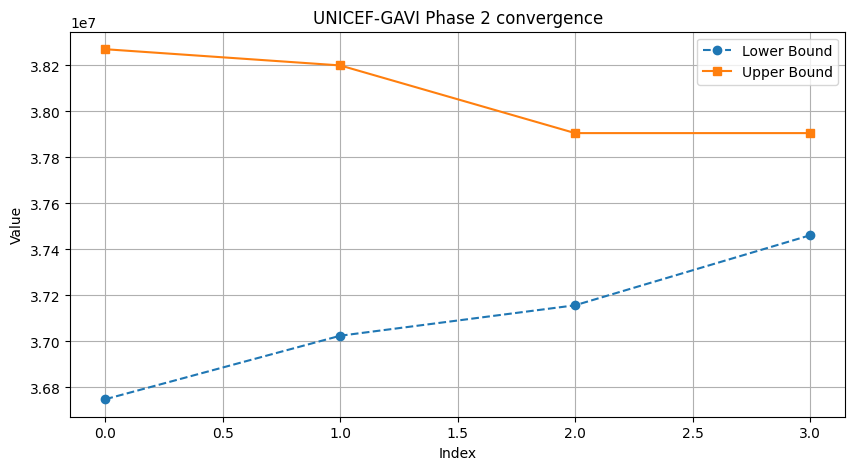

In [9]:
import matplotlib.pyplot as plt

# Create figure and plot data
plt.figure(figsize=(10, 5))
plt.plot(range(len(lb)), lb, label="Lower Bound", linestyle='dashed', marker='o')
plt.plot(range(len(ub)), ub, label="Upper Bound", linestyle='solid', marker='s')
plt.xlabel("Index")
plt.ylabel("Value")
plt.title("UNICEF-GAVI Phase 2 convergence")
plt.legend()
plt.grid(True)
plt.savefig("unicef_gavi_Convergence_phase_two.pdf")
plt.show()
